In [ ]:
#!pip install SoccerNet
import SoccerNet
from SoccerNet.Downloader import SoccerNetDownloader
mySoccerNetDownloader=SoccerNetDownloader(LocalDirectory = "")
mySoccerNetDownloader.password = ""
import os, cv2, imageio.v2 as imageio
from IPython.display import Image as IPyImage, display
import glob
import json
import numpy as np 
from ultralytics import YOLO
from tqdm import tqdm
import matplotlib.pyplot as plt
import shutil
import random
from collections import defaultdict, Counter
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import io
import imageio.v2 as imageio          # make sure this is installed


### Download Data

In [ ]:
mySoccerNetDownloader=SoccerNetDownloader(LocalDirectory="SoccerNetJersey")
mySoccerNetDownloader.downloadDataTask(task="jersey-2023", split=["train","test","challenge"])

### Explore dataset: 

Preview single video (sequence of frames)


Frames found: 465


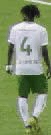

In [33]:
folder = "./SoccerNetJersey/jersey-2023/train/images/0"

# List all .jpg files and sort them numerically by the index in the filename
frames = sorted(
    [f for f in os.listdir(folder) if f.lower().endswith(".jpg")],
    key=lambda x: int(x.split("_")[1].split(".")[0])
)

print("Frames found:", len(frames))

# Read the first frame to get the expected height and width
first = cv2.imread(os.path.join(folder, frames[0]))
H, W = first.shape[:2]

imgs = []
for f in frames:
    img = cv2.imread(os.path.join(folder, f))
    if img is None:
        continue
    if img.shape[:2] != (H, W): # Ensure every frame matches the resolution of the first one
        img = cv2.resize(img, (W, H))
    imgs.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # Convert BGR (OpenCV default) to RGB for proper color display

#Build a GIF and display in notebook
buf = io.BytesIO()
imageio.mimsave(buf, imgs, format="GIF", fps=8)  # builds GIF in memory, not on disk
buf.seek(0)
display(IPyImage(data=buf.read(), format='gif'))




# Pick appropriate frames only
For train and test data

**!Change initial triples to switch to other directory** 

Explanation: 

This script implements a pose-guided, rules-based filtering pipeline whose purpose is to automatically extract clean, back-facing torso crops of a single player from raw video frames. The framework consists of three stages:
- **Data enumeration** – reading frame folders defined by a ground-truth JSON and batching them for processing.
- **Pose-based person selection**: After enumerating frame folders specified by the metadata file, the method processes images in batches and applies YOLO-Pose (Ultralytics YOLOv8-Pose)—a single-stage detection architecture that jointly predicts person bounding boxes and 17 COCO skeletal keypoints. The model produces, for each detected human, both spatial localization (bounding boxes) and anatomical landmark coordinates (shoulders, hips, face points), enabling precise geometric reasoning about body orientation and visibility.
- **Quality-controlled cropping** – rescaling keypoints back to the original image, deriving a padded torso region, and applying geometric (shoulder width), visibility (face confidence), and sharpness (Laplacian variance) criteria before saving the final crop.

In short, the code forms a systematic pipeline that isolates the main player and extracts a consistent, high-quality torso dataset by combining pose estimation with explicit filtering rules.

In [ ]:
#Directory for train dataset
ROOT_DIR   = "/SoccerNetJersey/jersey-2023/train"
TEST_GT    = os.path.join(ROOT_DIR, "train_gt.json")
OUTPUT_DIR = os.path.join(ROOT_DIR, "images_back_crops_train")

# OR

#Directory for test dataset
#ROOT_DIR   = "/SoccerNetJersey/jersey-2023/test"
#TEST_GT    = os.path.join(ROOT_DIR, "test_gt.json")
#OUTPUT_DIR = os.path.join(ROOT_DIR, "images_back_crops_test")


IMAGES_DIR = os.path.join(ROOT_DIR, "images")
MODEL_PATH = "/SoccerNetJersey/yolov8n-pose.pt" #Ready YOLO pose model weights (trained for person keypoints); downloaded from the web
# ==========================================================

DEVICE = "cpu"
IMGSZ  = 384    #input size for YOLO
BATCH  = 32     # number of frames processed per forward pass

# Heuristics for filtering good back-facing torso crops
SCALE_FACTOR   = 3.0   # upscale factor for pose inference (higher res → better keypoints)
FACE_CONF_THR  = 0.30  # if face conf >= 0.3 -> front shot -> reject
SHOULDER_MIN   = 20.0  # min shoulder distance; trying to filter out side shots (we want clear back)
BLUR_THRESHOLD = 10.0  # minimum Laplacian variance on crop (sharpness)
PADDING        = 0.15  # relative padding around torso bounding box


# COCO keypoint indices used, inherent within the model
NOSE, L_EYE, R_EYE = 0, 1, 2
L_SH, R_SH, L_HIP, R_HIP = 5, 6, 11, 12


def list_images(folder):
    """Return sorted list of full image paths inside a folder."""
    return sorted(
        os.path.join(folder, f)
        for f in os.listdir(folder)
    )

def lap_var(bgr):
    """Compute Laplacian variance (blur metric) on a BGR image."""
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def best_person_index(res):
    """Get largest human box (assumes camera focus on him) per frame and store coordinates"""
    if res.boxes is None or len(res.boxes) == 0:
        return None
    boxes = res.boxes.xyxy.cpu().numpy()
    areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    return int(np.argmax(areas))


def safe_torso_crop_from_original(img_orig, kpts_orig_xy, pad=PADDING):
    """
    Crop torso region from ORIGINAL image using shoulders + hips keypoints.

    - Uses L/R shoulder and L/R hip points to define a bounding box.
    - Adds relative padding `pad` around it.
    - Returns None if box is invalid or outside image bounds.
    """

    # Take only the 4 keypoints: [L_SH, R_SH, L_HIP, R_HIP]
    pts = kpts_orig_xy[[L_SH, R_SH, L_HIP, R_HIP], :]
    if np.isnan(pts).any():
        # Some keypoints missing → can't crop safely
        return None
    
    # Compute tight box around these points
    x1, y1 = float(np.min(pts[:, 0])), float(np.min(pts[:, 1]))
    x2, y2 = float(np.max(pts[:, 0])), float(np.max(pts[:, 1]))
    if x2 <= x1 or y2 <= y1:
        return None

    h, w = img_orig.shape[:2]
    dx, dy = (x2 - x1) * pad, (y2 - y1) * pad

    # Expand box by padding and clamp to image boundaries
    X1 = max(int(x1 - dx), 0)
    Y1 = max(int(y1 - dy), 0)
    X2 = min(int(x2 + dx), w - 1)
    Y2 = min(int(y2 + dy), h - 1)

    if X2 <= X1 or Y2 <= Y1:
        return None

    crop = img_orig[Y1:Y2, X1:X2]
    return crop if crop.size else None


def main():

    # Ensure output root directory exists
    os.makedirs(OUTPUT_DIR, exist_ok=True)

    #load folder list from test_gt.json
    with open(TEST_GT, "r") as f:
        gt = json.load(f)   # {"0": 4, "1": 93...}

    # skip label -1 and folders that don't exist under IMAGES_DIR
    folders = [
        folder_id for folder_id, y in gt.items()
        if (isinstance(y, int) and y != -1 and
            os.path.isdir(os.path.join(IMAGES_DIR, folder_id)))
    ]
    # Sort folder IDs
    folders = sorted(folders, key=lambda x: (len(x), x))

    print(f"Test folders to process (y != -1): {len(folders)}")

    # Load YOLO pose model
    model = YOLO(MODEL_PATH)

    # Iterate over each player folder
    for folder in tqdm(folders, desc="Folders", ncols=100):
        src = os.path.join(IMAGES_DIR, folder)  # input frames directory
        dst = os.path.join(OUTPUT_DIR, folder)  # output crops directory

        # resume: skip if already processed and non-empty
        if os.path.exists(dst) and len(os.listdir(dst)) > 0:
            continue
        os.makedirs(dst, exist_ok=True)

        # No frames in folder: skip
        img_paths = list_images(src)
        if not img_paths:
            continue

        # Process frames in batches for efficiency
        for i in range(0, len(img_paths), BATCH):
            batch_paths = img_paths[i:i + BATCH]

            orig_imgs = []  # images at original resolution
            up_imgs = []    # upscaled images for pose estimation
            for p in batch_paths:
                img = cv2.imread(p)
                if img is None:
                    orig_imgs.append(None)
                    up_imgs.append(None)
                    continue
                orig_imgs.append(img)

                # Upscale image for pose detection (improves keypoint quality)
                up = cv2.resize(
                    img, None,
                    fx=SCALE_FACTOR, fy=SCALE_FACTOR,
                    interpolation=cv2.INTER_CUBIC
                )
                up_imgs.append(up)
             # Filter out None entries; YOLO takes only valid images
            inps = [im for im in up_imgs if im is not None]
            if not inps:
                continue

            # Run pose model on each batch
            results = model.predict(
                inps,
                imgsz=IMGSZ,
                conf=0.25,
                device=DEVICE,
                verbose=False,
                batch=len(inps)
            )

            res_idx = 0
            for idx, path in enumerate(batch_paths):
                #Process only valid images and upscales
                img_orig = orig_imgs[idx]
                img_up   = up_imgs[idx]
                if img_orig is None or img_up is None:
                    continue

                res = results[res_idx]
                res_idx += 1
                
                # Skip frames with no detected keypoints
                if res.keypoints is None or len(res.keypoints.xy) == 0:
                    continue
                
                # Select main person (largest bounding box)
                j = best_person_index(res)
                if j is None:
                    continue

                # keypoints + confidences on UPSCALED image
                kxy_up = res.keypoints.xy[j].cpu().numpy()   # [17,2]
                kcf    = res.keypoints.conf[j].cpu().numpy() # [17]

                # back-facing rule: face keypoints must be low
                face_conf = float(np.nanmean(kcf[[NOSE, L_EYE, R_EYE]]))
                if face_conf >= FACE_CONF_THR:
                    continue

                # rescale keypoints back to original image coords
                kxy_orig = kxy_up / SCALE_FACTOR

                # shoulder distance check in original pixels
                shoulder_dist = float(np.linalg.norm(
                    kxy_orig[L_SH] - kxy_orig[R_SH]
                ))
                if shoulder_dist <= SHOULDER_MIN:
                    continue

                # torso crop from original
                torso = safe_torso_crop_from_original(img_orig, kxy_orig, pad=PADDING)
                if torso is None:
                    continue

                # Blur filter: reject very blurry crops
                if lap_var(torso) < BLUR_THRESHOLD:
                    continue
                
                # Save final torso crop;
                out_path = os.path.join(dst, os.path.basename(path))
                ok = cv2.imwrite(out_path, torso)

    print(f"Done. Test crops saved under: {OUTPUT_DIR}")

main()

In [ ]:
# Get folders info
count_non_empty = 0
count_empty = 0
total_images = 0

for folder in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, folder)
    if not os.path.isdir(fpath):
        continue
    images = [f for f in os.listdir(fpath) if f.lower().endswith(('.jpg'))]
    if images:
        count_non_empty += 1
        total_images += len(images)
    else:
        count_empty += 1

print(f"Total folders: {count_non_empty + count_empty}")
print(f"Non-empty folders: {count_non_empty}")
print(f"Empty folders: {count_empty}")
print(f"Total cropped images: {total_images}")
if count_non_empty:
    print(f"Avg images per valid folder: {total_images / count_non_empty:.1f}")

# Train yolo for sharp cutting the numbers out of whole back_shots

Although the torso crops isolate the correct visible number region, they are still not good enoguh to achieve more than 45-50% recognition score (player names, sponsors, grass, etc.) Cropping additionaly the back crops, did not achieve improving the training data. 

Therefore we trained a supervised digit detector, from a subset of approximately 250 torso images, which were manually annotated using Makesense.ai (an online annotation platform). These labels consist of YOLO-format text files giving the coordinates of the digits bounding boxes. This additionally helped us in cleaning general incosistencies from the data (many folders labeled as number 1, were actually ball tracking)

The following code block constructs a complete YOLO dataset from these annotations. It pairs each .txt label file with its corresponding torso image, filters out mismatches, and organizes the dataset according to the YOLO directory hierarchy ([images/train,labels/train], [images/val;  labels/val])

The annotated samples are then randomly shuffled and split into training (80%) and validation (20%) subsets. This organization is required by the YOLO training framework so that the model can load images, parse labels, and evaluate validation metrics correctly. The resulting dataset, combined with a YAML configuration file describing class names and directory paths, forms the basis for supervised training.


In [14]:
LABELS_SRC = "./SoccerNetJersey/our_digits_yolo_crop/labels_my-project-name_2025-11-18-02-34-42"   # folder with only .txt from makesense.ai
IMAGES_SRC = "./SoccerNetJersey/our_digits_yolo_crop/picked_for_training"      # folder with the images you annotated
DATASET_ROOT = "./SoccerNetJersey"  # where to build YOLO dataset
TRAIN_SPLIT = 0.8
# =========================

# make target dirs
img_train_dir = os.path.join(DATASET_ROOT, "our_digits_yolo_crop", "images", "train")
img_val_dir   = os.path.join(DATASET_ROOT, "our_digits_yolo_crop", "images", "val")
lab_train_dir = os.path.join(DATASET_ROOT, "our_digits_yolo_crop", "labels", "train")
lab_val_dir   = os.path.join(DATASET_ROOT, "our_digits_yolo_crop", "labels", "val")

os.makedirs(img_train_dir, exist_ok=True)
os.makedirs(img_val_dir,   exist_ok=True)
os.makedirs(lab_train_dir, exist_ok=True)
os.makedirs(lab_val_dir,   exist_ok=True)

# collect all label files from makesense.ai
label_paths = glob.glob(os.path.join(LABELS_SRC, "*.txt"))
if not label_paths:
    raise RuntimeError(f"No .txt files found in {LABELS_SRC}")

paired = [] #store (image_path, label_path) pairs

# For each label file, find the image with the same base name
for lab in label_paths:
    base = os.path.splitext(os.path.basename(lab))[0]
    img_path = os.path.join(IMAGES_SRC, base + ".jpg")

    # Only keep the pair if the matching image exists
    if not os.path.exists(img_path):
        continue

    paired.append((img_path, lab))

if not paired:
    raise RuntimeError("No image/label pairs found. Check LABELS_SRC and IMAGES_SRC.")

print(f"Found {len(paired)} image/label pairs.")

# Shuffle and split into train/validation sets
random.shuffle(paired)
split_idx = int(len(paired) * TRAIN_SPLIT)
train_pairs = paired[:split_idx]
val_pairs   = paired[split_idx:]


def copy_pairs(pairs, split):
    """Prepare dataset for required YOLO format"""
    img_dst = img_train_dir if split == "train" else img_val_dir
    lab_dst = lab_train_dir if split == "train" else lab_val_dir
    for img, lab in pairs:
        img_name = os.path.basename(img)
        lab_name = os.path.basename(lab)
        shutil.copy2(img, os.path.join(img_dst, img_name))
        shutil.copy2(lab, os.path.join(lab_dst, lab_name))

# Copy train/val samples to destination folders
copy_pairs(train_pairs, "train")
copy_pairs(val_pairs,   "val")

print(f"Train images: {len(train_pairs)}")
print(f"Val images:   {len(val_pairs)}")
print(f"Dataset root: {DATASET_ROOT}")

Found 264 image/label pairs.
Train images: 211
Val images:   53
Dataset root: ./SoccerNetJersey


Using the curated dataset, the next block trains a YOLOv8n (nano) detection model. YOLOv8n is a compact, computationally efficient variant of the YOLOv8 family, offering rapid training and capabilities of high-quality detection on small objects such as jersey digits. The configuration trains up to 80 epochs with early stopping (patience=10), and also resizes the images as it is required by YOLO (batch images, align detection head, use pretrained weights correctly, and maintain efficient, stable training and inference.

In [26]:
# Train YOLO-number detector so that it learns to recognize custom objects (jersey digits).

# Path to YAML config
yaml_path = "SoccerNetJersey/our_digits_yolo_crop/digit.yaml"

# Launch YOLOv8 detection training using the Ultralytics CLI
!yolo detect train \                
    model=yolov8n.pt \                  
    data="{yaml_path}" \
    imgsz=320 \
    epochs=80 \
    batch=16 \
    device=cpu \
    patience=10

New https://pypi.org/project/ultralytics/8.3.229 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.226 🚀 Python-3.12.2 torch-2.5.1 CPU (Apple M3 Pro)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=SoccerNetJersey/our_digits_yolo_crop/digit.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=80, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=No

After training the digit-detection model, the final stage of the pipeline applies the learned YOLOv8 weights to the full set of torso crops previously extracted by the pose-based module. The objective is to automatically isolate the region containing the jersey number from each back-view torso image. 
    - The script loads the fine-tuned model (best.pt)
    - Each player’s images are organized into per-player folders, and this folder structure is preserved in the output to maintain dataset coherence.
    - The function crop_with_yolo iterates through every torso image, runs YOLO inference in batches, and retrieves the model’s bounding-box predictions for the digit.

 Using a confidence threshold, only detections with sufficient confidence are retained. For each valid prediction, the script selects the highest-confidence bounding box, clamps its coordinates to valid image boundaries, and extracts a tight crop of the predicted digit region. 

In [ ]:
#Apply the trained model to the back crops
ROOT = "./SoccerNetJersey/jersey-2023"

TRAIN_SRC = os.path.join(ROOT, "train", "images_back_crops_train")
TEST_SRC  = os.path.join(ROOT, "test",  "images_back_crops_test")

TRAIN_DST = os.path.join(ROOT, "train", "number_crops_yolo_train")
TEST_DST  = os.path.join(ROOT, "test",  "number_crops_yolo_test")

MODEL_PATH = "./runs/detect/train/weights/best.pt"
CONF_THRES = 0.5   # minimum confidence for keeping a box
IMGSZ      = 320   # YOLO inference image size

def list_images(folder):
    """Return sorted list of full image paths inside a folder."""
    return sorted(
        os.path.join(folder, f)
        for f in os.listdir(folder)
    )

def ensure_dir(p):
    """Create directory if it does not already exist."""
    os.makedirs(p, exist_ok=True)

def crop_with_yolo(model, src_root, dst_root, split_name="train"):
    """Run YOLO digit detection on all torso crops inside from source directory, 
    and save the digit-only crops into destination directory, keeping folder structure"""
    
    if not os.path.isdir(src_root):
        print(f"[{split_name}] Source does not exist: {src_root}")
        return

    ensure_dir(dst_root)

    # Each folder corresponds to one player number
    folders = [d for d in os.listdir(src_root)
               if os.path.isdir(os.path.join(src_root, d))]
    folders.sort(key=lambda x: (len(x), x))

    print(f"[{split_name}] Found {len(folders)} folders in {src_root}")

    total_imgs = 0
    total_crops = 0

    # Process each player folder
    for folder in tqdm(folders, desc=f"YOLO cropping {split_name}", ncols=100):
        src_f = os.path.join(src_root, folder)  # folder containing torso crops
        dst_f = os.path.join(dst_root, folder)  # output folder for digit crops
        ensure_dir(dst_f)

        img_paths = list_images(src_f)
        if not img_paths:
            continue

        total_imgs += len(img_paths)

        # run YOLO on this folder's images in one batch
        results = model.predict(
            img_paths,
            conf=CONF_THRES,
            imgsz=IMGSZ,
            verbose=False
        )
        # For each image and its corresponding YOLO result
        for img_path, res in zip(img_paths, results):
            img = cv2.imread(img_path)
            if img is None:
                continue

            # Skip if no number was detected
            if res.boxes is None or len(res.boxes) == 0:
                # no detection → skip (or optionally save original)
                continue

            # take the highest-confidence box
            boxes = res.boxes.xyxy.cpu().numpy()
            confs = res.boxes.conf.cpu().numpy()
            idx   = int(np.argmax(confs))
            x1, y1, x2, y2 = boxes[idx]
            h, w = img.shape[:2]

            # Clamp coordinates to valid image boundaries
            x1 = max(0, int(x1))
            y1 = max(0, int(y1))
            x2 = min(w, int(x2))
            y2 = min(h, int(y2))

            if x2 <= x1 or y2 <= y1:
                continue
            
            # Extract the digit region from the torso image
            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            
            # Save the digit crop using the same filename as the torso crop
            out_path = os.path.join(dst_f, os.path.basename(img_path))
            cv2.imwrite(out_path, crop)
            total_crops += 1

    # Summary for this split
    print(f"[{split_name}] Images seen:  {total_imgs}")
    print(f"[{split_name}] Crops saved: {total_crops}")
    print(f"[{split_name}] Output root: {dst_root}\n")

# Load the trained YOLO digit detector
model = YOLO(MODEL_PATH)

# Run digit detection on train and test torso crops
crop_with_yolo(model, TRAIN_SRC, TRAIN_DST, split_name="train")
crop_with_yolo(model, TEST_SRC,  TEST_DST,  split_name="test")

# Model training

 Training an EfficientNet-B0 classifier to recognize jersey numbers (0–99) from the digit crops produced by the YOLO detector. It constructs a custom JerseyNumberDatasetCapped that loads YOLO-generated digit images grouped by player/track folder and applies a hard cap of MAX_PER_CLASS = 300 images per jersey number to reduce class imbalance and prevent overfitting to overrepresented digits. Each image is resized to a fixed resolution and augmented during training, then normalized with standard ImageNet statistics. 
 The EffB0JerseyClassifier replaces the final layer of EfficientNet-B0 with a 100-way linear classifier, and a standard supervised training loop optimizes the network using cross-entropy loss, AdamW, cosine learning-rate scheduling, and gradient clipping. 


In [ ]:
ROOT = "./SoccerNetJersey/jersey-2023"

# Paths to training data and YOLO-generated digit crops
TRAIN_ROOT       = os.path.join(ROOT, "train")
TRAIN_CROPS_DIR  = os.path.join(TRAIN_ROOT, "number_crops_yolo_train") 
TRAIN_GT         = os.path.join(TRAIN_ROOT, "train_gt.json")

# store EfficientNet-B0 checkpoints
CKPT_DIR         = "./SoccerNetJersey/checkpoints_EffNetB0_capp300"
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_PATH_BEST   = os.path.join(CKPT_DIR, "EffNetB0_capp300_best.pt")
CKPT_PATH_LAST   = os.path.join(CKPT_DIR, "EffNetB0_capp300_last.pt")
# ====================================

# ---------- TRAINING CONFIG ----------
NUM_CLASSES   = 100         # jersey numbers 0–99
EPOCHS        = 25
BATCH_SIZE    = 64
LR            = 3e-4
WEIGHT_DECAY  = 5e-2
NUM_WORKERS   = 0           # set >0 if using multi-process dataloading
SEED          = 42

IMG_SIZE      = (128, 128)  # resolution for all digit crops
MAX_PER_CLASS = 300         # hard cap per jersey number (to reduce class imbalance)
# ------------------------------------


def set_seed(seed=SEED):
    """Fix random seeds for reproducibility."""
    random.seed(seed)
    torch.manual_seed(seed)


class JerseyNumberDatasetCapped(Dataset):
    """
    PyTorch dataset over YOLO digit crops, with a per-class cap.

    For each jersey number y, we randomly sample at most `max_per_class`
    image paths. This prevents overrepresented jersey numbers from dominating
    the training set and reduces the risk of overfitting to frequent classes.
    """
    def __init__(
        self,
        crops_dir,
        gt_json,
        img_size=(128, 128),
        max_per_class=300,
        train=True,
        seed=123
    ):
        self.crops_dir      = crops_dir
        self.train          = train
        self.img_size       = img_size
        self.max_per_class  = max_per_class

        # Ground-truth mapping from folder name: jersey number
        with open(gt_json, "r") as f:
            self.gt = json.load(f)

        # Group all image paths by integer label
        by_label = defaultdict(list)

        # One folder per player / track; each contains multiple digit crops
        folders = [
            d for d in os.listdir(crops_dir)
            if os.path.isdir(os.path.join(crops_dir, d))
        ]
        # Sort for stable ordering (useful for debugging / logging)
        folders.sort(key=lambda x: (len(x), x))

        for folder in folders:
            # Skip folders without a label in the GT file
            if folder not in self.gt:
                continue

            y_int = self.gt[folder]
            # Ignore invalid labels
            if y_int < 0 or y_int >= NUM_CLASSES:
                continue

            fpath = os.path.join(crops_dir, folder)
            imgs = sorted(glob.glob(os.path.join(fpath, "*.jpg")))
            if not imgs:
                continue

            for p in imgs:
                by_label[y_int].append(p)

        # Apply per-class cap using a fixed RNG for reproducibility
        rng = random.Random(seed)
        self.items = []  # list of (img_path, label_int)

        print("Per-number image counts BEFORE capping:")
        for y_int in sorted(by_label.keys()):
            n = len(by_label[y_int])
            print(f"  #{y_int}: {n} images")

        print(f"\nApplying cap of {max_per_class} images per number.\n")

        for y_int, paths in by_label.items():
            # If we have more than max_per_class samples, randomly downsample
            if len(paths) > max_per_class:
                paths = rng.sample(paths, max_per_class)
            # Collect final (path, label) pairs
            for p in paths:
                self.items.append((p, y_int))

        print(f"Total images AFTER capping: {len(self.items)}")

        # Standard ImageNet normalization for EfficientNet backbone
        IMAGENET_MEAN = (0.485, 0.456, 0.406)
        IMAGENET_STD  = (0.229, 0.224, 0.225)

        # Slightly stronger augmentation for training; deterministic resize for val
        if train:
            self.tfms = transforms.Compose([
                transforms.Resize(img_size),
                transforms.RandomRotation(degrees=8),
                transforms.ColorJitter(brightness=0.15, contrast=0.15),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ])
        else:
            self.tfms = transforms.Compose([
                transforms.Resize(img_size),
                transforms.ToTensor(),
                transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            ])

        split_name = "train" if train else "val"
        print(f"[{split_name}] Unique labels: {len(by_label)}")

    def __len__(self):
        """Total number of (image, label) pairs after capping."""
        return len(self.items)

    def __getitem__(self, i):
        """
        Load an image from disk, apply transforms, and return:
          x: Tensor image
          y: integer label in [0, NUM_CLASSES)
          path: original file path (useful for debugging/analysis)
        """
        path, y = self.items[i]
        img = Image.open(path).convert("RGB")
        x = self.tfms(img)
        return x, y, path


class EffB0JerseyClassifier(nn.Module):
    """
    EfficientNet-B0 backbone with the final classifier layer
    replaced by a NUM_CLASSES-way linear layer for jersey numbers.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        try:
            # Prefer explicit ImageNet weights if available
            weights = EfficientNet_B0_Weights.IMAGENET1K_V1
        except Exception:
            weights = EfficientNet_B0_Weights.DEFAULT

        eff = efficientnet_b0(weights=weights)

        # Replace the last classification layer with our own
        in_features = eff.classifier[1].in_features
        eff.classifier[1] = nn.Linear(in_features, num_classes)
        self.model = eff

    def forward(self, x):
        return self.model(x)
    

def train():
    """Train EfficientNet-B0 on capped YOLO digit-crop dataset."""
    set_seed(SEED)

    device = "mps" if torch.backends.mps.is_available() else "cpu"
    print("Device:", device)

    # Build training dataset and dataloader
    ds = JerseyNumberDatasetCapped(
        TRAIN_CROPS_DIR,
        TRAIN_GT,
        img_size=IMG_SIZE,
        max_per_class=MAX_PER_CLASS,
        train=True,
        seed=SEED,
    )
    loader = DataLoader(
        ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=(device != "cpu"),
    )

    # Initialize classifier and optimization components
    model = EffB0JerseyClassifier().to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    criterion = nn.CrossEntropyLoss()

    best_loss = float("inf")

    # Standard supervised training loop
    for epoch in range(1, EPOCHS + 1):
        model.train()
        running_loss, running_correct, running_total = 0.0, 0, 0

        pbar = tqdm(loader, desc=f"Epoch {epoch}/{EPOCHS}", ncols=100, leave=False)
        for xb, yb, _paths in pbar:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()

            # Gradient clipping for stability
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item() * xb.size(0)
            preds = logits.argmax(dim=1)
            running_correct += (preds == yb).sum().item()
            running_total += xb.size(0)

            pbar.set_postfix({
                "loss": f"{loss.item():.4f}",
                "acc": f"{(running_correct / max(1, running_total)) * 100:.1f}%"
            })

        epoch_loss = running_loss / max(1, running_total)
        epoch_acc = running_correct / max(1, running_total) * 100.0
        scheduler.step()

        print(
            f"[Epoch {epoch}/{EPOCHS}] "
            f"loss={epoch_loss:.4f} acc={epoch_acc:.2f}% "
            f"lr={scheduler.get_last_lr()[0]:.2e}"
        )

        # save the "last" checkpoint
        torch.save(
            {
                "model": model.state_dict(),
                "cfg": {
                    "img_size": IMG_SIZE,
                    "num_classes": NUM_CLASSES,
                    "max_per_class": MAX_PER_CLASS,
                },
            },
            CKPT_PATH_LAST,
        )

        # Update and save the "best" checkpoint (by lowest loss)
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            torch.save(
                {
                    "model": model.state_dict(),
                    "cfg": {
                        "img_size": IMG_SIZE,
                        "num_classes": NUM_CLASSES,
                        "max_per_class": MAX_PER_CLASS,
                    },
                },
                CKPT_PATH_BEST,
            )
            print(f"new best, saved to {CKPT_PATH_BEST}")

    print("Training finished. Best loss:", best_loss)


train()

Device: mps
Per-number image counts BEFORE capping:
  #1: 95 images
  #3: 1086 images
  #4: 1350 images
  #5: 414 images
  #6: 1162 images
  #7: 166 images
  #8: 1527 images
  #9: 2377 images
  #10: 3654 images
  #11: 744 images
  #14: 2690 images
  #15: 572 images
  #16: 993 images
  #17: 229 images
  #18: 2 images
  #19: 47 images
  #20: 712 images
  #21: 160 images
  #22: 314 images
  #23: 866 images
  #24: 1497 images
  #25: 906 images
  #26: 544 images
  #27: 763 images
  #28: 1563 images
  #29: 816 images
  #30: 867 images
  #31: 596 images
  #32: 1 images
  #33: 1842 images
  #34: 342 images
  #35: 7 images
  #36: 1101 images
  #38: 12 images
  #40: 223 images
  #44: 1022 images
  #50: 559 images
  #55: 335 images
  #56: 3 images
  #62: 566 images
  #93: 227 images

Applying cap of 300 images per number.

Total images AFTER capping: 9872
[train] Unique labels: 41


[Epoch 1/25] loss=1.7227 acc=60.14% lr=2.99e-04
new best, saved to ./SoccerNetJersey/checkpoints_EffNetB0_capp300/EffNetB0_capp300_best.pt


[Epoch 2/25] loss=0.3741 acc=91.46% lr=2.95e-04
new best, saved to ./SoccerNetJersey/checkpoints_EffNetB0_capp300/EffNetB0_capp300_best.pt


[Epoch 3/25] loss=0.2415 acc=93.90% lr=2.89e-04
new best, saved to ./SoccerNetJersey/checkpoints_EffNetB0_capp300/EffNetB0_capp300_best.pt


[Epoch 4/25] loss=0.1775 acc=95.18% lr=2.81e-04
new best, saved to ./SoccerNetJersey/checkpoints_EffNetB0_capp300/EffNetB0_capp300_best.pt


...

[Epoch 21/25] loss=0.0041 acc=99.88% lr=1.86e-05
new best, saved to ./SoccerNetJersey/checkpoints_EffNetB0_capp300/EffNetB0_capp300_best.pt


[Epoch 22/25] loss=0.0040 acc=99.88% lr=1.05e-05
new best, saved to ./SoccerNetJersey/checkpoints_EffNetB0_capp300/EffNetB0_capp300_best.pt


[Epoch 23/25] loss=0.0040 acc=99.88% lr=4.71e-06
new best, saved to ./SoccerNetJersey/checkpoints_EffNetB0_capp300/EffNetB0_capp300_best.pt


[Epoch 24/25] loss=0.0042 acc=99.90% lr=1.18e-06


[Epoch 25/25] loss=0.0025 acc=99.94% lr=0.00e+00
new best, saved to ./SoccerNetJersey/checkpoints_EffNetB0_capp300/EffNetB0_capp300_best.pt
Training finished. Best loss: 0.002524548420204058


# Evaluation

Evaluate the trained EfficientNet-B0 jersey-number classifier on the test set of YOLO digit crops. It first rebuilds the same EfficientNet-B0 architecture used during training, loads the best checkpoint, and switches the model to evaluation mode. For each player folder in the test directory, all digit crops are loaded, preprocessed with the same resizing and ImageNet normalization as in training, and passed through the network in batches. The model produces a class prediction for every crop, and these frame-level predictions are combined into a single folder-level jersey-number prediction via majority vote. The script then compares this prediction with the ground-truth label for each folder, accumulates the number of correct and total predictions, and finally reports both the overall player-level accuracy and a detailed per-jersey-number accuracy breakdown.

In [ ]:
ROOT = "./SoccerNetJersey/jersey-2023"

# Test split paths
TEST_ROOT      = os.path.join(ROOT, "test")
TEST_CROPS_DIR = os.path.join(TEST_ROOT, "number_crops_yolo_test")  # YOLO digit crops (test)
TEST_GT        = os.path.join(TEST_ROOT, "test_gt.json")            # folder → jersey number

# EfficientNet-B0 checkpoint 
CKPT_PATH_BEST = "./SoccerNetJersey/checkpoints_EffNetB0_capp300/EffNetB0_capp300_best.pt"

NUM_CLASSES = 100
IMG_SIZE = (128, 128)   # must match training resolution (H, W)
# ====================================

class EffB0JerseyClassifier(nn.Module):
    """
    EfficientNet-B0 backbone with its final classifier replaced
    by a NUM_CLASSES-way linear layer for jersey numbers.
    """
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        try:
            weights = EfficientNet_B0_Weights.IMAGENET1K_V1
        except Exception:
            weights = EfficientNet_B0_Weights.DEFAULT

        eff = efficientnet_b0(weights=weights)
        in_features = eff.classifier[1].in_features
        eff.classifier[1] = nn.Linear(in_features, num_classes)
        self.model = eff

    def forward(self, x):
        return self.model(x)


def build_transform(img_size):
    """
    Deterministic preprocessing used at test time:
    resize + convert to tensor + ImageNet normalization.
    """
    IMAGENET_MEAN = (0.485, 0.456, 0.406)
    IMAGENET_STD  = (0.229, 0.224, 0.225)
    return transforms.Compose([
        transforms.Resize(img_size),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def list_images(folder):
    """Return all .jpg image paths in a given folder."""
    return [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(".jpg")
    ]


def predict_folder(model, tfm, device, folder_path, batch_size=128):
    """
    Run the classifier on all digit crops in a folder and return
    a single folder-level prediction via majority vote.
    Each folder corresponds to one player / jersey number and
    contains multiple YOLO digit crops from different frames.
    """
    img_paths = list_images(folder_path)
    if not img_paths:
        return None  # no crops → no prediction

    preds = []

    # Process crops in mini-batches for efficiency
    for i in range(0, len(img_paths), batch_size):
        batch_files = img_paths[i:i + batch_size]
        imgs = []
        for p in batch_files:
            img = Image.open(p).convert("RGB")
            imgs.append(tfm(img))
        xb = torch.stack(imgs, 0).to(device)

        with torch.no_grad():
            logits = model(xb)                 # shape [B, NUM_CLASSES]
            batch_pred = logits.argmax(dim=1).cpu().tolist()
        preds.extend(batch_pred)

    if not preds:
        return None

    # Majority vote over all frame-level predictions
    counter = Counter(preds)
    best_label, _ = counter.most_common(1)[0]
    return best_label


def main():
    device = "mps" if torch.backends.mps.is_available() else "cpu"
    print("Device:", device)

    # Load model + best checkpoint weights
    ckpt = torch.load(CKPT_PATH_BEST, map_location=device)
    model = EffB0JerseyClassifier(num_classes=NUM_CLASSES).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()

    # Test-time transform (same normalization as training, no augmentation)
    tfm = build_transform(IMG_SIZE)

    # Ground-truth mapping: folder name → jersey number
    with open(TEST_GT, "r") as f:
        gt = json.load(f)

    # All player folders in the test crops directory
    folders = [
        d for d in os.listdir(TEST_CROPS_DIR)
        if os.path.isdir(os.path.join(TEST_CROPS_DIR, d))
    ]
    folders.sort(key=lambda x: (len(x), x))

    total, correct = 0, 0
    # Per-number statistics: for each jersey number store ok / total
    per_num = defaultdict(lambda: {"ok": 0, "tot": 0})

    for folder in tqdm(folders, desc="Evaluating", ncols=100):
        folder_path = os.path.join(TEST_CROPS_DIR, folder)

        if folder not in gt:
            continue
        y_true = gt[folder]
        # Skip invalid labels (e.g. ball = -1)
        if y_true < 0 or y_true >= NUM_CLASSES:
            continue

        pred = predict_folder(model, tfm, device, folder_path)
        if pred is None:
            # Empty folder → ignored for statistics (could be handled differently)
            continue

        total += 1
        if pred == y_true:
            correct += 1
            per_num[str(y_true)]["ok"] += 1
        per_num[str(y_true)]["tot"] += 1

    # Overall folder-level (player-level) accuracy
    acc = 100.0 * correct / max(1, total)
    print(f"\nFolder-level accuracy: {acc:.2f}%  ({correct}/{total})")

    # Per-jersey-number accuracy breakdown
    print("\nPer-number accuracy:")
    for num in sorted(per_num.keys(), key=lambda x: (len(x), int(x))):
        stats = per_num[num]
        a = 100.0 * stats["ok"] / max(1, stats["tot"])
        print(f"  #{num}: {a:.1f}%  ({stats['ok']}/{stats['tot']})")


main()

Device: mps


/var/folders/0v/7x58msc10bg_fvpsvzv25bvh0000gn/T/ipykernel_61830/3349642975.py:114: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH_BEST, map_locat


Folder-level accuracy: 64.89%  (427/658)

Per-number accuracy:
  #1: 75.0%  (3/4)
  #3: 83.3%  (5/6)
  #4: 57.6%  (19/33)
  #5: 73.7%  (14/19)
  #7: 85.7%  (18/21)
  #8: 96.2%  (25/26)
  #9: 81.1%  (30/37)
  #10: 88.7%  (47/53)
  #11: 16.7%  (3/18)
  #14: 84.8%  (56/66)
  #15: 63.2%  (12/19)
  #16: 9.5%  (2/21)
  #17: 0.0%  (0/4)
  #18: 0.0%  (0/1)
  #20: 95.2%  (20/21)
  #21: 0.0%  (0/1)
  #22: 100.0%  (6/6)
  #23: 92.3%  (12/13)
  #24: 80.0%  (8/10)
  #25: 89.3%  (25/28)
  #26: 100.0%  (15/15)
  #27: 20.0%  (3/15)
  #30: 0.0%  (0/9)
  #31: 42.1%  (8/19)
  #32: 0.0%  (0/5)
  #33: 35.7%  (15/42)
  #34: 85.0%  (17/20)
  #36: 23.3%  (10/43)
  #38: 0.0%  (0/1)
  #43: 0.0%  (0/1)
  #44: 18.8%  (3/16)
  #50: 85.7%  (18/21)
  #53: 0.0%  (0/1)
  #55: 91.7%  (11/12)
  #56: 0.0%  (0/1)
  #59: 0.0%  (0/5)
  #62: 88.9%  (8/9)
  #69: 0.0%  (0/1)
  #93: 100.0%  (14/14)
  #99: 0.0%  (0/1)
